# CIC heatmap (1970 vs 2022)


In [18]:
# Load dependencies and make src/ importable from the notebook.
from pathlib import Path
import sys
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()
sys.path.insert(0, str(root.parent / "src"))
    
from utils_cic_geo_merge import *


# Load and check null

In [19]:
# Merge CIC data with commune/arrondissement geometries.
gdf = merge_cic_communes_then_arrondissements(verbose=True)

Dropping the following communes/arrondissements with missing geometry:
<StringArray>
['SANNERVILLE', 'BERNIERES-SUR-SEINE']
Length: 2, dtype: string


In [20]:
# Check missing values per column.
gdf.isna().sum().sort_values(ascending=False)

code_insee     2131092
code              2290
dep                  0
nomdep               0
codecommune          0
nomcommune           0
plm                  0
paris                0
value                0
metric               0
year                 0
geometry             0
dtype: int64

# Check overlappings between polygons are irrelevant.

In [21]:
# Compute total pairwise overlap area between unique commune geometries.
gdf_unique = gdf.groupby("codecommune").first().reset_index(drop=True)
g = gdf_unique.reset_index(drop=True)[["geometry"]].copy()

pairs = gpd.sjoin(g, g, predicate="intersects", how="inner")
pairs = pairs[pairs.index < pairs.index_right]

geom_left = g.loc[pairs.index, "geometry"].to_numpy()
geom_right = g.loc[pairs.index_right, "geometry"].to_numpy()

intersect_area = gpd.GeoSeries(geom_left).intersection(gpd.GeoSeries(geom_right)).area.sum()


In [22]:
# Compare overlap area to the total covered area.
tot_area = gdf_unique.geometry.union_all().area

print(np.round(intersect_area/tot_area,4))

0.0007


# Preliminary analysis (prixbien)

In [23]:
mask = gdf["metric"]=="prixbien"
gdf_prixbien = gdf[mask]

In [24]:
gdf_prixbien.head()

,dep,nomdep,codecommune,nomcommune,plm,paris,value,metric,year,code,geometry,code_insee
0,01,AIN,01001,ABERGEMENT-CLEMENCIAT,0,0,11428.6520,prixbien,1970,01001,"POLYGON ((4.90936 46.12916, 4.90894 46.13251, ...",<NA>
1,01,AIN,01002,ABERGEMENT-DE-VAREY,0,0,6747.6401,prixbien,1970,01002,"POLYGON ((5.40437 46.00782, 5.40891 46.01386, ...",<NA>
2,01,AIN,01004,AMBERIEU-EN-BUGEY,0,0,9386.2725,prixbien,1970,01004,"POLYGON ((5.34128 45.94839, 5.3395 45.94992, 5...",<NA>
3,01,AIN,01005,AMBERIEUX-EN-DOMBES,0,0,11259.5210,prixbien,1970,01005,"POLYGON ((4.88717 46.01575, 4.88863 46.01644, ...",<NA>
4,01,AIN,01006,AMBLEON,0,0,8527.9121,prixbien,1970,01006,"POLYGON ((5.58134 45.74066, 5.57797 45.74575, ...",<NA>


count    1.835950e+06
mean     7.610038e+04
std      6.638161e+04
min      2.855505e+02
25%      2.814522e+04
50%      5.632249e+04
75%      1.080066e+05
max      1.878612e+06
Name: value, dtype: float64


<Axes: ylabel='Frequency'>

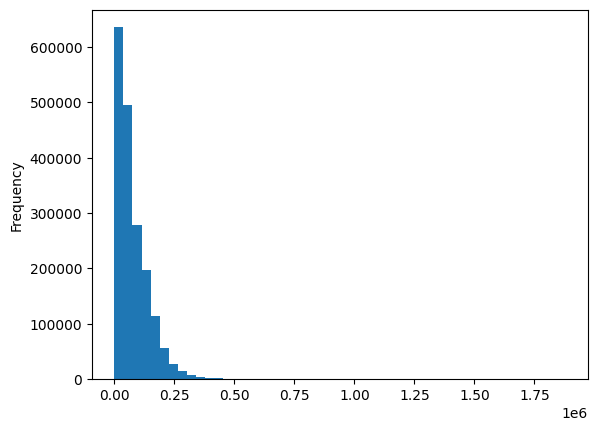

In [31]:
# Distribution of value.
print(gdf_prixbien["value"].describe())
gdf_prixbien["value"].plot.hist(bins=50)


<Axes: xlabel='year'>

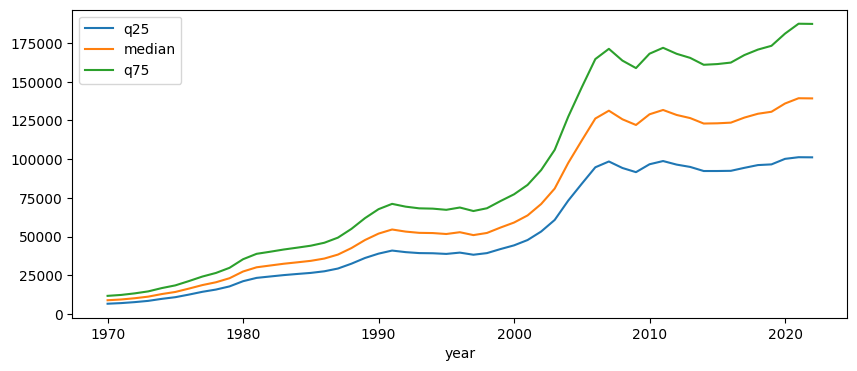

In [26]:
# Distribution of value by year (quartiles).
year_q = (
    gdf_prixbien.groupby("year")["value"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
)
year_q.columns = ["q25", "median", "q75"]
year_q.plot(figsize=(10, 4))


<Axes: xlabel='dep'>

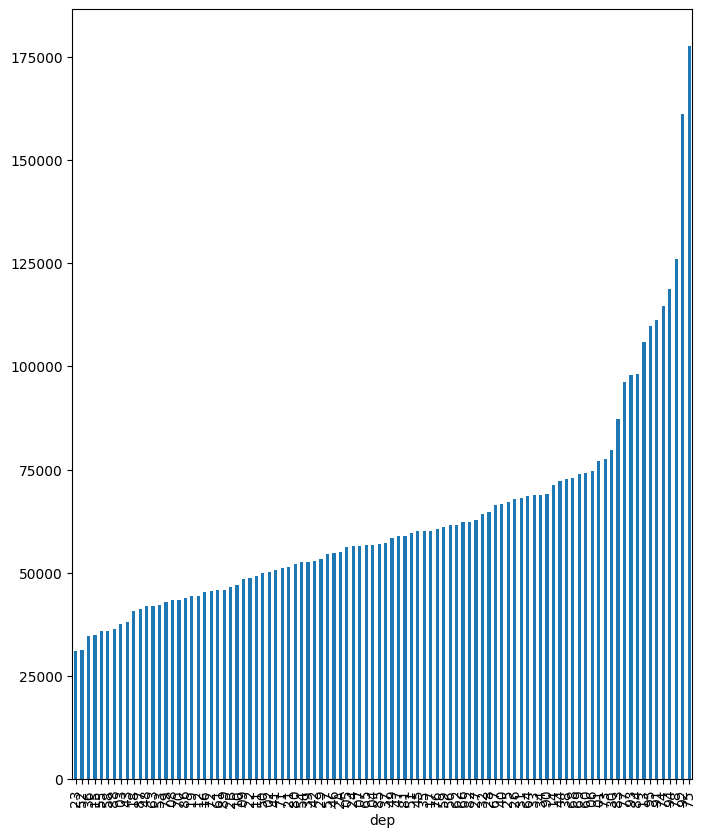

In [35]:
# Distribution of value by dep (median).
dep_median = gdf_prixbien.groupby("dep")["value"].median().sort_values()
dep_median.plot(kind="bar", figsize=(8, 10))


Text(0.5, 1.0, 'Median prixbien by dep and year (top 20 deps)')

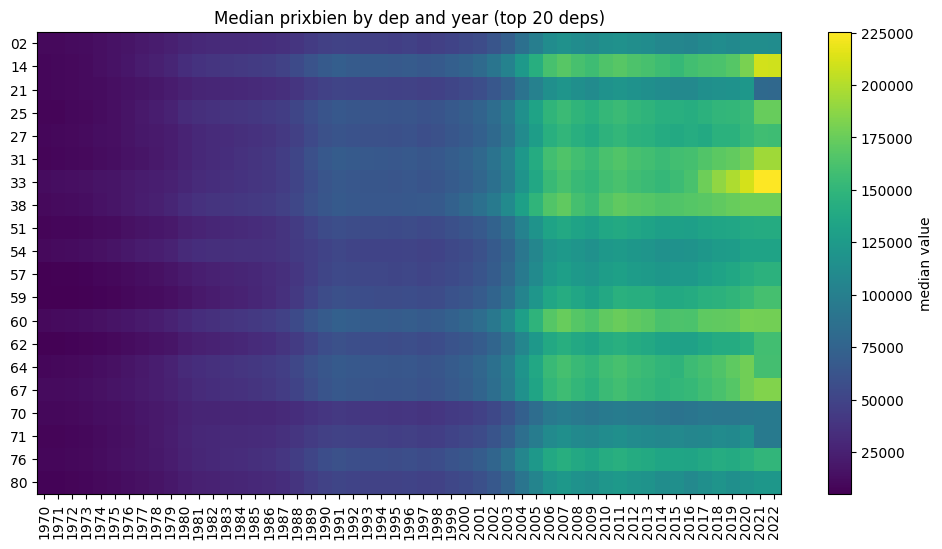

In [28]:
# Distribution of value by dep and year (median heatmap for top deps).
top_deps = (
    gdf_prixbien.groupby("dep")["value"].count().sort_values(ascending=False).head(20).index
)
dep_year = (
    gdf_prixbien[gdf_prixbien["dep"].isin(top_deps)]
    .pivot_table(index="dep", columns="year", values="value", aggfunc="median")
)
plt.figure(figsize=(12, 6))
plt.imshow(dep_year, aspect="auto")
plt.yticks(range(len(dep_year.index)), dep_year.index)
plt.xticks(range(len(dep_year.columns)), dep_year.columns, rotation=90)
plt.colorbar(label="median value")
plt.title("Median prixbien by dep and year (top 20 deps)")


In [ ]:
# Basic outlier cleanup using IQR. coefficient of 2.5 to leave fat tails.
q1 = gdf_prixbien["value"].quantile(0.25)
q3 = gdf_prixbien["value"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 2.5 * iqr
upper = q3 + 2.5 * iqr
gdf_prixbien_clean = gdf_prixbien[gdf_prixbien["value"].between(lower, upper)]
print(
    f"Dropped {len(gdf_prixbien) - len(gdf_prixbien_clean)} rows as outliers,"
    f"{len(gdf_prixbien_clean) / len(gdf_prixbien) - 1}, of the total"
)


Dropped 15014 rows as outliers,-0.008177782619352425, of the total


count    1.820936e+06
mean     7.344996e+04
std      5.880240e+04
min      2.855505e+02
25%      2.794925e+04
50%      5.575136e+04
75%      1.062794e+05
max      3.076600e+05
Name: value, dtype: float64


<Axes: ylabel='Frequency'>

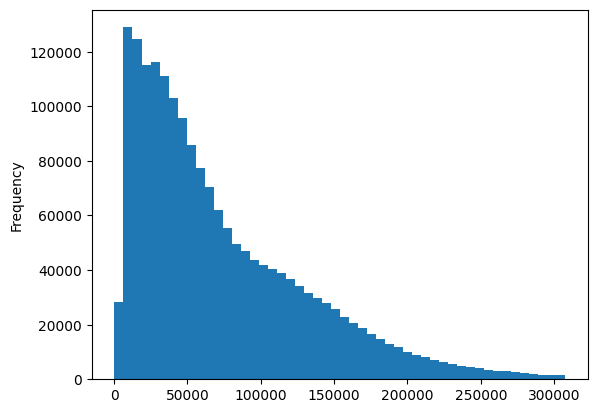

In [46]:
# Distribution of value.
print(gdf_prixbien_clean["value"].describe())
gdf_prixbien_clean["value"].plot.hist(bins=50)

# Preliminary analysis (prixm2)

In [36]:
# Create a prixm2-only GeoDataFrame for analysis.
mask = gdf["metric"] == "prixm2"
gdf_prixm2 = gdf[mask]
gdf_prixm2.head()


,dep,nomdep,codecommune,nomcommune,plm,paris,value,metric,year,code,geometry,code_insee
1834065,01,AIN,01001,ABERGEMENT-CLEMENCIAT,0,0,1918.0977,prixm2,2014,01001,"POLYGON ((4.90936 46.12916, 4.90894 46.13251, ...",<NA>
1834066,01,AIN,01002,ABERGEMENT-DE-VAREY,0,0,1259.0839,prixm2,2014,01002,"POLYGON ((5.40437 46.00782, 5.40891 46.01386, ...",<NA>
1834067,01,AIN,01004,AMBERIEU-EN-BUGEY,0,0,2073.9475,prixm2,2014,01004,"POLYGON ((5.34128 45.94839, 5.3395 45.94992, 5...",<NA>
1834068,01,AIN,01005,AMBERIEUX-EN-DOMBES,0,0,2066.0977,prixm2,2014,01005,"POLYGON ((4.88717 46.01575, 4.88863 46.01644, ...",<NA>
1834069,01,AIN,01006,AMBLEON,0,0,1551.2677,prixm2,2014,01006,"POLYGON ((5.58134 45.74066, 5.57797 45.74575, ...",<NA>


count    297432.000000
mean       1531.522238
std         872.852374
min          39.646008
25%        1007.791800
50%        1339.027550
75%        1801.940250
max       24983.373000
Name: value, dtype: float64


<Axes: ylabel='Frequency'>

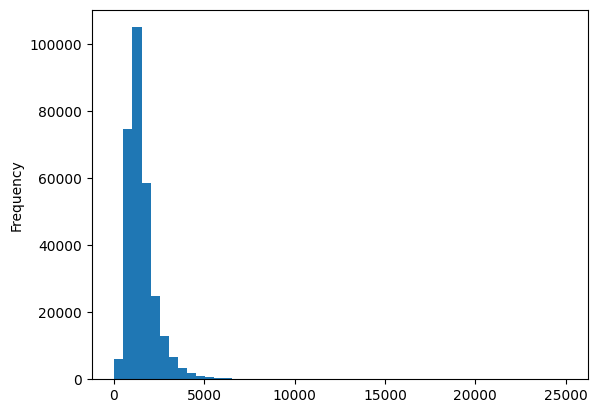

In [37]:
# Distribution of value.
print(gdf_prixm2["value"].describe())
gdf_prixm2["value"].plot.hist(bins=50)


<Axes: xlabel='year'>

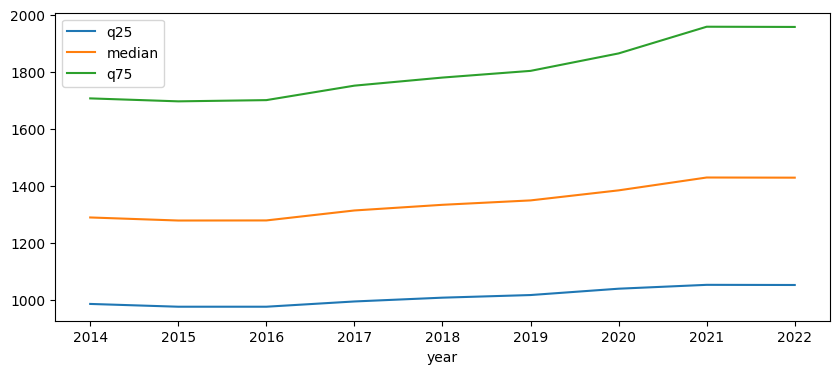

In [38]:
# Distribution of value by year (quartiles).
year_q = (
    gdf_prixm2.groupby("year")["value"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
)
year_q.columns = ["q25", "median", "q75"]
year_q.plot(figsize=(10, 4))


<Axes: xlabel='dep'>

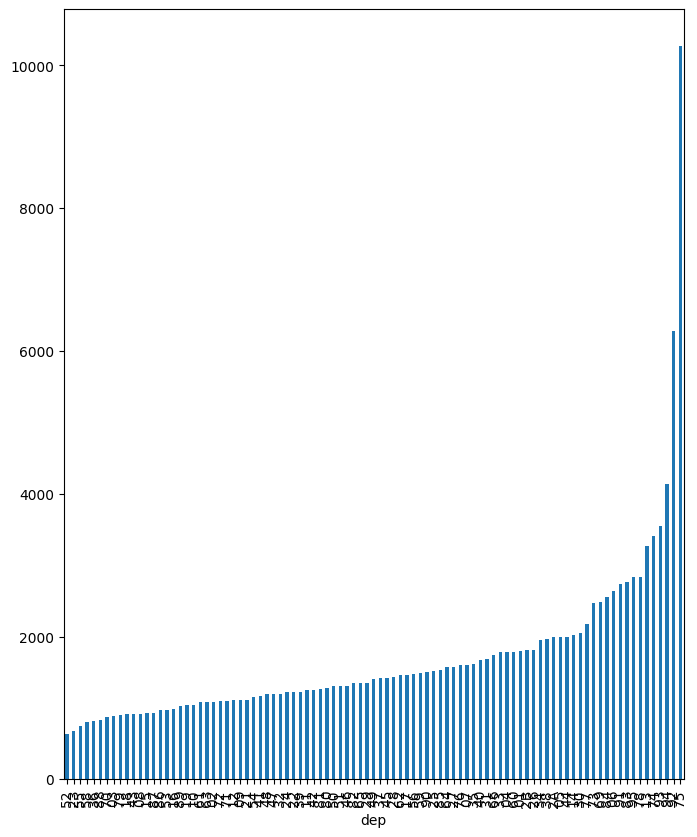

In [39]:
# Distribution of value by dep (median).
dep_median = gdf_prixm2.groupby("dep")["value"].median().sort_values()
dep_median.plot(kind="bar", figsize=(8, 10))


Text(0.5, 1.0, 'Median prixm2 by dep and year (top 20 deps)')

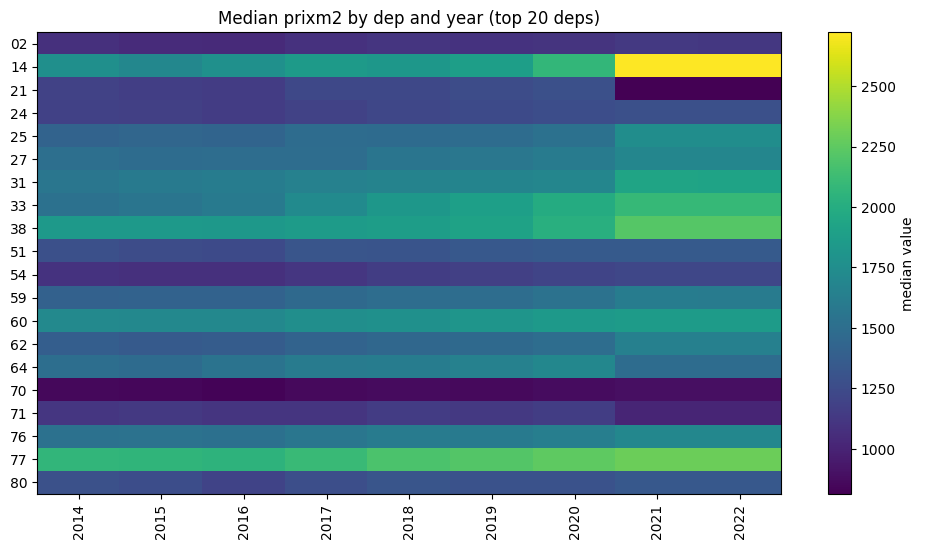

In [40]:
# Distribution of value by dep and year (median heatmap for top deps).
top_deps = (
    gdf_prixm2.groupby("dep")["value"].count().sort_values(ascending=False).head(20).index
)
dep_year = (
    gdf_prixm2[gdf_prixm2["dep"].isin(top_deps)]
    .pivot_table(index="dep", columns="year", values="value", aggfunc="median")
)
plt.figure(figsize=(12, 6))
plt.imshow(dep_year, aspect="auto")
plt.yticks(range(len(dep_year.index)), dep_year.index)
plt.xticks(range(len(dep_year.columns)), dep_year.columns, rotation=90)
plt.colorbar(label="median value")
plt.title("Median prixm2 by dep and year (top 20 deps)")


In [47]:
# Basic outlier cleanup using IQR.
q1 = gdf_prixm2["value"].quantile(0.25)
q3 = gdf_prixm2["value"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 2.5 * iqr
upper = q3 + 2.5 * iqr
gdf_prixm2_clean = gdf_prixm2[gdf_prixm2["value"].between(lower, upper)]
print(
    f"Dropped {len(gdf_prixm2) - len(gdf_prixm2_clean)} rows as outliers,"
    f"{len(gdf_prixm2_clean) / len(gdf_prixm2) - 1}, of the total"
)


Dropped 6301 rows as outliers,-0.021184674144006044, of the total


count    291131.000000
mean       1453.270126
std         638.603427
min          39.646008
25%        1000.605900
50%        1323.538600
75%        1761.924050
max        3787.239000
Name: value, dtype: float64


<Axes: ylabel='Frequency'>

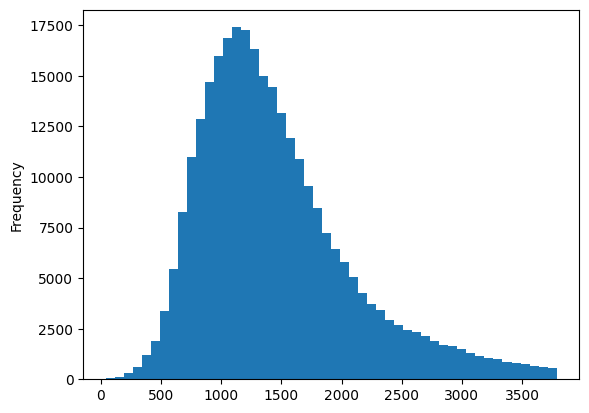

In [48]:
# Distribution of value.
print(gdf_prixm2_clean["value"].describe())
gdf_prixm2_clean["value"].plot.hist(bins=50)

In [ ]:
# Plot heatmaps for two reference years.
years = ["1970", "2022"]
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, year in zip(axes, years):
    subset = gdf[gdf["year"] == year]
    subset.plot(
        column="value",
        ax=ax,
        legend=True,
        cmap="viridis",
        missing_kwds={"color": "lightgrey", "label": "Missing"},
    )
    ax.set_title(f"CIC value in {year}")
    ax.set_axis_off()

plt.tight_layout()
